## Import libraries

In [4]:
from __future__ import annotations

import argparse
import os
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.helpers import ensure_dir, normalize_product_label, normalize_text, word_count
from src.eda import run_eda
from src.preprocessing import preprocess_data

## Load dataset

In [6]:
df = pd.read_csv("../data/raw/complaints.csv")

df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_14952\3032069356.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/complaints.csv")


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


## Dataset overview

In [7]:
print(f"Dataset Shape: {df.shape}")

df.info()

Dataset Shape: (9609797, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), 

## Missing values

In [9]:
# Count missing values
missing_values = df.isnull().sum()

# Percentage of missing values
missing_percent = (missing_values / len(df)) * 100

missing_summary = (
    pd.DataFrame({
        "Missing Values": missing_values,
        "Percentage": missing_percent
    })
    .sort_values("Missing Values", ascending=False)
)

missing_summary

,Missing Values,Percentage
Tags,8981029,93.457011
Consumer disputed?,8841498,92.005044
Consumer complaint narrative,6629041,68.982113
Company public response,4770207,49.638999
Consumer consent provided?,1649561,17.165409
Sub-issue,839522,8.736105
Sub-product,235295,2.448491
State,54516,0.567296
ZIP code,30228,0.314554
Company response to consumer,20,0.000208


## Remove rows without complaint narratives

In [10]:
print(f"Original dataset shape: {df.shape}")

df = df.dropna(subset=["Consumer complaint narrative"])

print(f"After removing missing narratives: {df.shape}")

Original dataset shape: (9609797, 18)
After removing missing narratives: (2980756, 18)


In [11]:
df = df[df["Consumer complaint narrative"].str.strip() != ""]

print(f"After removing empty narratives: {df.shape}")

After removing empty narratives: (2980756, 18)


## Distribution of complaints by product

In [12]:
product_counts = df["Product"].value_counts()

product_counts

Product
Credit reporting or other personal consumer reports                             1091253
Credit reporting, credit repair services, or other personal consumer reports     807281
Debt collection                                                                  336076
Checking or savings account                                                      140319
Mortgage                                                                         130160
Credit card or prepaid card                                                      108667
Money transfer, virtual currency, or money service                                97188
Credit card                                                                       80667
Student loan                                                                      53209
Vehicle loan or lease                                                             39577
Credit reporting                                                                  31587
Payday loan, title loan,

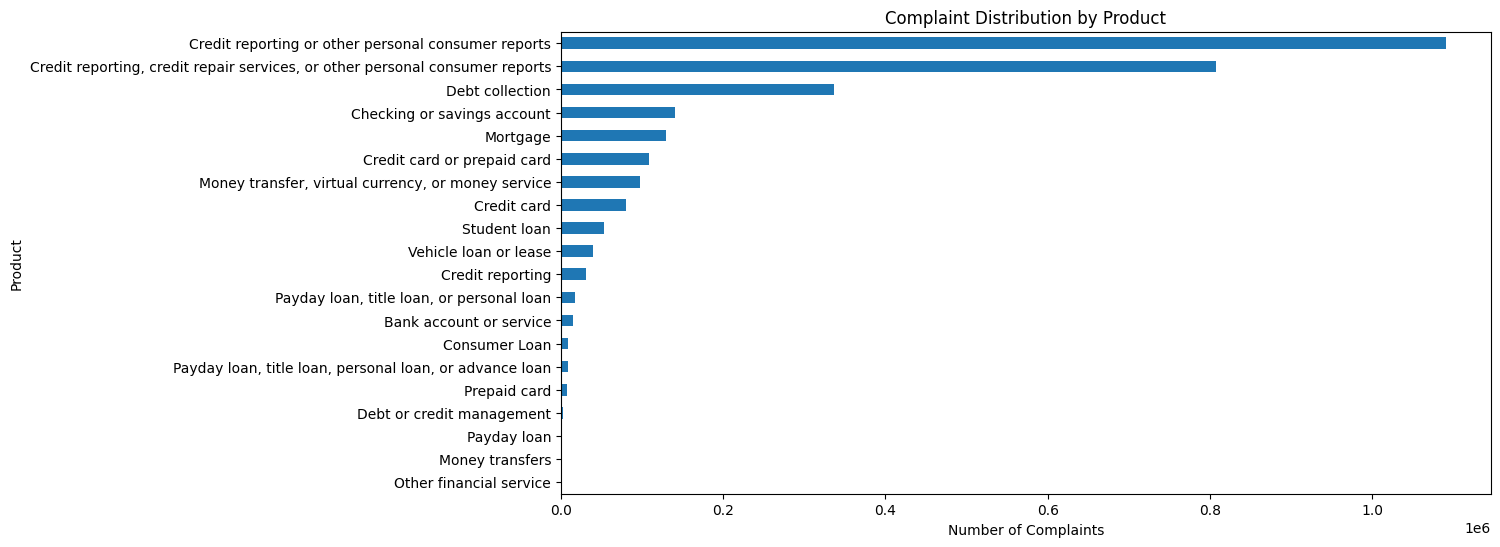

In [13]:
plt.figure(figsize=(12,6))

product_counts.head(20).sort_values().plot(kind="barh")

plt.title("Complaint Distribution by Product")
plt.xlabel("Number of Complaints")

plt.show()

## Consumer narratives

In [14]:
with_narrative = df["Consumer complaint narrative"].notna().sum()
without_narrative = df["Consumer complaint narrative"].isna().sum()

print("Complaints with narratives:", with_narrative)
print("Complaints without narratives:", without_narrative)

Complaints with narratives: 2980756
Complaints without narratives: 0


In [15]:
df["Narrative Length"] = (
    df["Consumer complaint narrative"]
    .fillna("")
    .apply(word_count)
)

df["Narrative Length"].describe()

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
Name: Narrative Length, dtype: float64

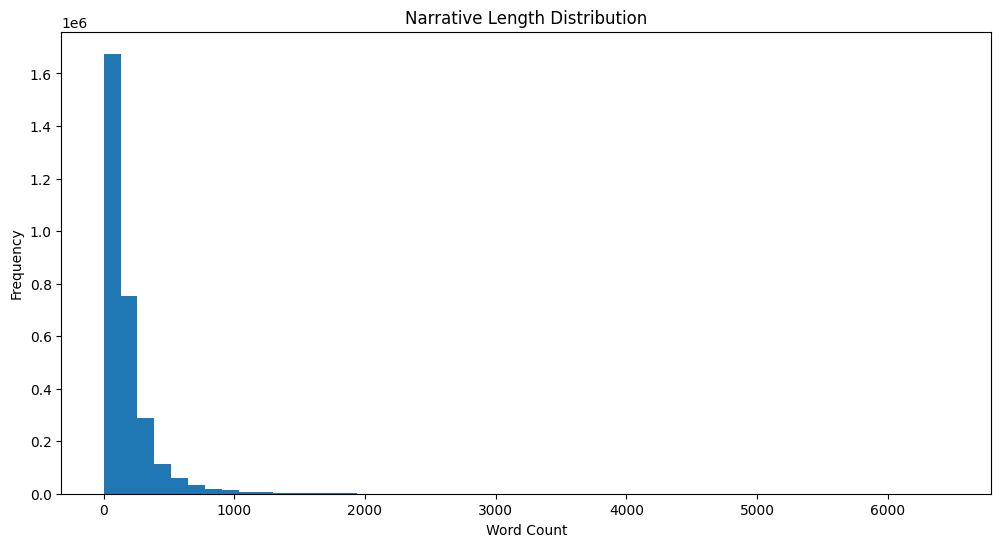

In [16]:
plt.figure(figsize=(12,6))

plt.hist(df["Narrative Length"], bins=50)

plt.title("Narrative Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

In [17]:
short = df[df["Narrative Length"] <= 5]

long = df[df["Narrative Length"] >= df["Narrative Length"].quantile(0.99)]

print("Very short narratives:", len(short))
print("Very long narratives:", len(long))

Very short narratives: 4871
Very long narratives: 30687


## Filter the required products

In [18]:
sorted(df["Product"].unique())

['Bank account or service',
 'Checking or savings account',
 'Consumer Loan',
 'Credit card',
 'Credit card or prepaid card',
 'Credit reporting',
 'Credit reporting or other personal consumer reports',
 'Credit reporting, credit repair services, or other personal consumer reports',
 'Debt collection',
 'Debt or credit management',
 'Money transfer, virtual currency, or money service',
 'Money transfers',
 'Mortgage',
 'Other financial service',
 'Payday loan',
 'Payday loan, title loan, or personal loan',
 'Payday loan, title loan, personal loan, or advance loan',
 'Prepaid card',
 'Student loan',
 'Vehicle loan or lease',
 'Virtual currency']

## Preprocess data

In [19]:
cleaned_df = preprocess_data(df)

cleaned_df.head()

,Complaint ID,Date received,product_normalized,Product,Sub-product,Issue,Sub-issue,narrative_clean,narrative_word_count_clean,Company,State,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?
12237,14069121,2025-06-13,Credit Card,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,a xxxx xxxx card was opened under my name by a...,91,"CITIBANK, N.A.",TX,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN
12532,14061897,2025-06-13,Savings Account,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,i made the mistake of using my wellsfargo debi...,108,WELLS FARGO & COMPANY,ID,Web,2025-06-13,Closed with explanation,Yes,NaN
13280,14047085,2025-06-12,Credit Card,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,dear cfpb i have a secured credit card with ci...,127,"CITIBANK, N.A.",NY,Web,2025-06-13,Closed with monetary relief,Yes,NaN
13506,14040217,2025-06-12,Credit Card,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,i have a citi rewards cards the credit balance...,234,"CITIBANK, N.A.",IL,Web,2025-06-12,Closed with explanation,Yes,NaN
13955,13968411,2025-06-09,Credit Card,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'i am writing to dispute the following charge...,503,"CITIBANK, N.A.",TX,Web,2025-06-09,Closed with monetary relief,Yes,NaN


In [20]:
print(cleaned_df.shape)

cleaned_df["product_normalized"].value_counts()

(524280, 16)


product_normalized
Credit Card        189332
Savings Account    155175
Money Transfer      98684
Personal Loan       81089
Name: count, dtype: int64

In [21]:
cleaned_df[["Product", "narrative_clean"]].head()

,Product,narrative_clean
12237,Credit card,a xxxx xxxx card was opened under my name by a...
12532,Checking or savings account,i made the mistake of using my wellsfargo debi...
13280,Credit card,dear cfpb i have a secured credit card with ci...
13506,Credit card,i have a citi rewards cards the credit balance...
13955,Credit card,b'i am writing to dispute the following charge...


## Save the cleaned dataset

In [22]:
cleaned_df.to_csv("../data/processed/cleaned_complaints.csv", index=False)